# GRANDE W&B Diagnostics Analysis

Starter notebook for inspecting `grande_diagnostics/*` metrics logged to Weights & Biases.

What it covers:
- scalar trends from init (`step=0`) through later epochs
- depth-wise feature-selection and threshold diagnostics
- estimator diversity, routing, and seed-stability metrics
- histogram drift over epochs for selected features, threshold z-scores, leaf occupancy, and effective estimator size
- optional gradient diagnostics if `grande_diagnostics_gradients=True` was enabled for the run

Important limitation:
- histogram keys are stored in W&B as histogram payloads (`bins` + `values`), not raw tensors. This notebook reconstructs approximate distributions from those bucket counts.


In [1]:
from __future__ import annotations

import math
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import wandb
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")‚
plt.rcParams["figure.figsize"] = (10, 4)

ENTITY = "raiizen1-university-of-mannheim"
PROJECT = "tabflex_new"
RUN_PATH = (
    "raiizen1-university-of-mannheim/tabflex_new/"
    "mn_childmodelgrande_d128_H128_e128_E3_"
    "grandedecodervariantfactorized_stats_"
    "grandediagnosticsTrue_grandediagnosticsh_9b51cfd3191e"
)

api = wandb.Api(timeout=60)


In [2]:
def get_run(run_path: str):
    return api.run(run_path)


def list_grande_keys(run, include_histograms: bool = True) -> list[str]:
    keys = sorted(key for key in run.summary.keys() if key.startswith("grande_diagnostics/"))
    if include_histograms:
        return keys
    return [key for key in keys if "/hists/" not in key]


def existing_keys(run, keys: Sequence[str]) -> list[str]:
    available = set(run.summary.keys())
    return [key for key in keys if key in available]


def depth_sorted_keys(keys: Sequence[str], prefix: str, suffix: str) -> list[str]:
    matched = [key for key in keys if key.startswith(prefix) and key.endswith(suffix)]

    def parse_depth(key: str) -> int:
        for part in key.split("/"):
            if "depth_" in part:
                return int(part.split("depth_")[1].split("_")[0])
        raise ValueError(f"no depth segment found in {key}")

    return sorted(matched, key=parse_depth)


def load_scalar_history(run, keys: Sequence[str]) -> pd.DataFrame:
    keys = ["_step", *existing_keys(run, keys)]
    rows = list(run.scan_history(keys=keys, page_size=500))
    if not rows:
        return pd.DataFrame(columns=keys)
    df = pd.DataFrame(rows).sort_values("_step").reset_index(drop=True)
    epoch_key = "grande_diagnostics/meta/epoch"
    if epoch_key in df.columns:
        df["epoch"] = df[epoch_key].fillna(df["_step"]) 
    else:
        df["epoch"] = df["_step"]
    return df


def histogram_to_frame(run, key: str) -> pd.DataFrame:
    rows = list(
        run.scan_history(
            keys=["_step", "grande_diagnostics/meta/epoch", key],
            page_size=500,
        )
    )
    records = []
    for row in rows:
        hist = row.get(key)
        if not hist or hist.get("_type") != "histogram":
            continue
        bins = hist["bins"]
        values = hist["values"]
        step = row["_step"]
        epoch = row.get("grande_diagnostics/meta/epoch", step)
        for bin_idx, count in enumerate(values):
            left = bins[bin_idx]
            right = bins[bin_idx + 1] if bin_idx + 1 < len(bins) else bins[bin_idx]
            center = 0.5 * (left + right)
            records.append(
                {
                    "_step": step,
                    "epoch": epoch,
                    "bin_idx": bin_idx,
                    "bin_left": left,
                    "bin_right": right,
                    "bin_center": center,
                    "count": float(count),
                }
            )
    return pd.DataFrame.from_records(records)


def metric_delta_table(df: pd.DataFrame, keys: Sequence[str]) -> pd.DataFrame:
    present = [key for key in keys if key in df.columns]
    if not present or df.empty:
        return pd.DataFrame(columns=["metric", "init", "last", "delta"])
    first = df.iloc[0]
    last = df.iloc[-1]
    rows = []
    for key in present:
        init_value = first[key]
        last_value = last[key]
        rows.append(
            {
                "metric": key,
                "init": init_value,
                "last": last_value,
                "delta": last_value - init_value,
            }
        )
    return pd.DataFrame(rows)


def plot_scalar_panel(df: pd.DataFrame, keys: Sequence[str], title: str, ax=None) -> None:
    if ax is None:
        _, ax = plt.subplots()
    for key in keys:
        if key in df.columns:
            ax.plot(df["epoch"], df[key], marker="o", label=key.split("/")[-1])
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.legend(loc="best")


def plot_depth_metric(df: pd.DataFrame, keys: Sequence[str], title: str, ax=None) -> None:
    if ax is None:
        _, ax = plt.subplots()
    for key in keys:
        if key not in df.columns:
            continue
        depth = [part for part in key.split("/") if part.startswith("depth_")][0]
        ax.plot(df["epoch"], df[key], marker="o", label=depth)
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.legend(loc="best")


def plot_histogram_heatmap(hist_df: pd.DataFrame, title: str, normalize: bool = False, ax=None) -> None:
    if hist_df.empty:
        return
    plot_df = hist_df.copy()
    value_col = "count"
    if normalize:
        totals = plot_df.groupby("epoch")["count"].transform("sum").replace(0, np.nan)
        plot_df["density"] = plot_df["count"] / totals
        value_col = "density"
    pivot = plot_df.pivot_table(index="epoch", columns="bin_center", values=value_col, fill_value=0.0)
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 4))
    sns.heatmap(pivot.sort_index(), cmap="viridis", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("bin center")
    ax.set_ylabel("epoch")


def plot_histogram_overlay(hist_df: pd.DataFrame, title: str, normalize: bool = True, ax=None) -> None:
    if hist_df.empty:
        return
    if ax is None:
        _, ax = plt.subplots()
    first_epoch = hist_df["epoch"].min()
    last_epoch = hist_df["epoch"].max()
    for epoch in (first_epoch, last_epoch):
        epoch_df = hist_df[hist_df["epoch"] == epoch].sort_values("bin_center")
        y = epoch_df["count"].to_numpy()
        if normalize and y.sum() > 0:
            y = y / y.sum()
        ax.plot(epoch_df["bin_center"], y, marker="o", label=f"epoch {int(epoch)}")
    ax.set_title(title)
    ax.set_xlabel("bin center")
    ax.legend(loc="best")


In [3]:
run = get_run(RUN_PATH)
grande_keys = list_grande_keys(run, include_histograms=True)
scalar_keys = list_grande_keys(run, include_histograms=False)

print(run.name)
print(f"Found {len(grande_keys)} grande_diagnostics keys in W&B")
display(pd.DataFrame({"key": grande_keys}))

scalar_df = load_scalar_history(run, scalar_keys)
display(scalar_df.head())


mn_childmodelgrande_d128_H128_e128_E3_grandedecodervariantfactorized_stats_grandediagnosticsTrue_grandediagnosticsh_9b51cfd3191e
Found 69 grande_diagnostics keys in W&B


,key
0,grande_diagnostics/context_seed/loss_mean
1,grande_diagnostics/context_seed/loss_range
2,grande_diagnostics/context_seed/loss_std
3,grande_diagnostics/context_seed/prediction_agr...
4,grande_diagnostics/context_seed/probability_va...
...,...
64,grande_diagnostics/thresholds/depth_2/max_abs
65,grande_diagnostics/thresholds/depth_2/mean
66,grande_diagnostics/thresholds/depth_2/std
67,grande_diagnostics/thresholds/depth_2/variance


,_step,grande_diagnostics/context_seed/loss_mean,grande_diagnostics/context_seed/loss_range,grande_diagnostics/context_seed/loss_std,grande_diagnostics/context_seed/prediction_agreement_mean,grande_diagnostics/context_seed/probability_variance_mean,grande_diagnostics/diversity/effective_dim_95,grande_diagnostics/diversity/leaf_cosine_mean,grande_diagnostics/diversity/split_index_cosine_mean,grande_diagnostics/diversity/threshold_cosine_mean,...,grande_diagnostics/thresholds/depth_1/std,grande_diagnostics/thresholds/depth_1/variance,grande_diagnostics/thresholds/depth_1/zscore_abs_mean,grande_diagnostics/thresholds/depth_2/extreme_fraction_abs_z_gt_3,grande_diagnostics/thresholds/depth_2/max_abs,grande_diagnostics/thresholds/depth_2/mean,grande_diagnostics/thresholds/depth_2/std,grande_diagnostics/thresholds/depth_2/variance,grande_diagnostics/thresholds/depth_2/zscore_abs_mean,epoch
0,0,0.694415,0.002656,0.001093,0.496816,0.000005,7,0.621343,0.666636,0.117669,...,0.129894,0.016873,0.048430,0.003906,0.442470,-0.028034,0.140963,0.019871,0.228342,0
1,1,0.694415,0.002656,0.001093,0.496816,0.000005,7,0.621343,0.666636,0.117669,...,0.129894,0.016873,0.048430,0.003906,0.442470,-0.028034,0.140963,0.019871,0.228342,1
2,2,0.693498,0.002002,0.000862,0.536581,0.000005,7,0.628653,0.663986,0.134299,...,0.129354,0.016732,0.050248,0.003906,0.449712,-0.028497,0.143918,0.020712,0.248682,2
3,3,0.693508,0.002507,0.000934,0.551667,0.000005,7,0.631371,0.663190,0.130365,...,0.130795,0.017107,0.050804,0.003906,0.449088,-0.028313,0.143360,0.020552,0.253851,3


,metric,init,last,delta
0,grande_diagnostics/output/loss,0.694664,0.694010,-0.000654
1,grande_diagnostics/output/accuracy,0.028462,0.030769,0.002308
2,grande_diagnostics/output/ece,0.077400,0.075405,-0.001995
3,grande_diagnostics/diversity/effective_dim_95,7.000000,7.000000,0.000000
4,grande_diagnostics/estimator_weights/effective...,7.959067,7.957128,-0.001940
5,grande_diagnostics/routing/dead_leaf_fraction,0.132812,0.140625,0.007812
6,grande_diagnostics/context_seed/loss_std,0.001093,0.000934,-0.000159
7,grande_diagnostics/context_seed/prediction_agr...,0.496816,0.551667,0.054850


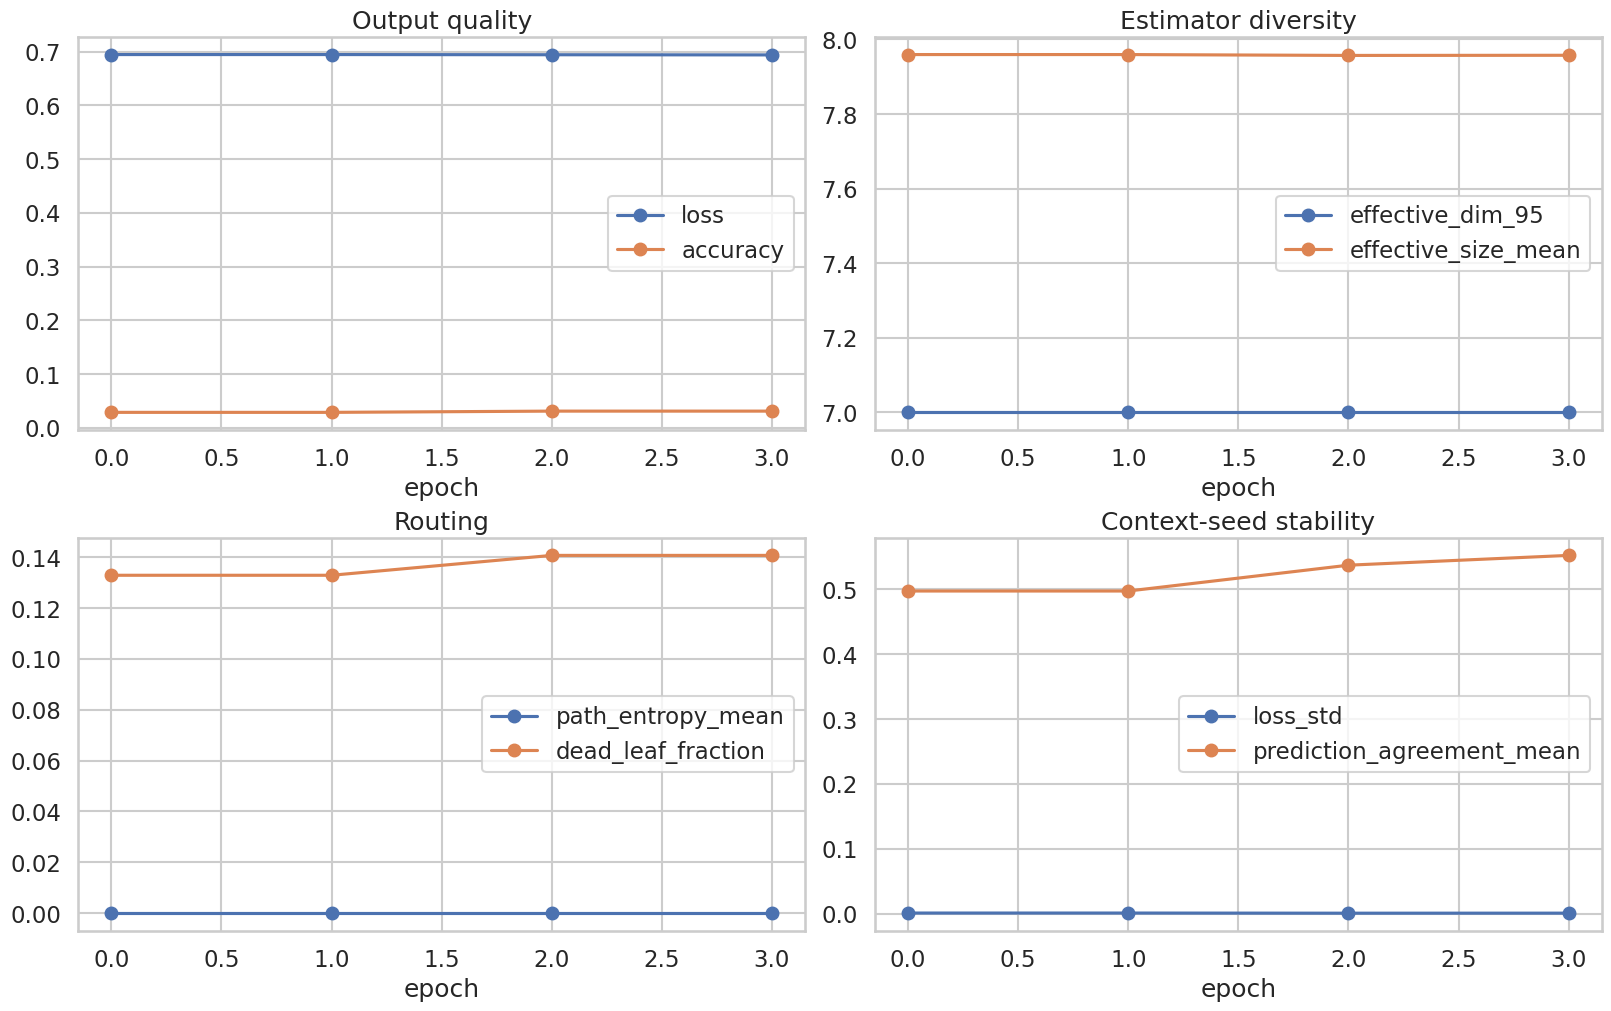

In [4]:
overview_keys = [
    "grande_diagnostics/output/loss",
    "grande_diagnostics/output/accuracy",
    "grande_diagnostics/output/ece",
    "grande_diagnostics/diversity/effective_dim_95",
    "grande_diagnostics/estimator_weights/effective_size_mean",
    "grande_diagnostics/routing/dead_leaf_fraction",
    "grande_diagnostics/context_seed/loss_std",
    "grande_diagnostics/context_seed/prediction_agreement_mean",
]

display(metric_delta_table(scalar_df, overview_keys))

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
plot_scalar_panel(
    scalar_df,
    ["grande_diagnostics/output/loss", "grande_diagnostics/output/accuracy"],
    title="Output quality",
    ax=axes[0, 0],
)
plot_scalar_panel(
    scalar_df,
    ["grande_diagnostics/diversity/effective_dim_95", "grande_diagnostics/estimator_weights/effective_size_mean"],
    title="Estimator diversity",
    ax=axes[0, 1],
)
plot_scalar_panel(
    scalar_df,
    ["grande_diagnostics/routing/path_entropy_mean", "grande_diagnostics/routing/dead_leaf_fraction"],
    title="Routing",
    ax=axes[1, 0],
)
plot_scalar_panel(
    scalar_df,
    ["grande_diagnostics/context_seed/loss_std", "grande_diagnostics/context_seed/prediction_agreement_mean"],
    title="Context-seed stability",
    ax=axes[1, 1],
)
plt.show()


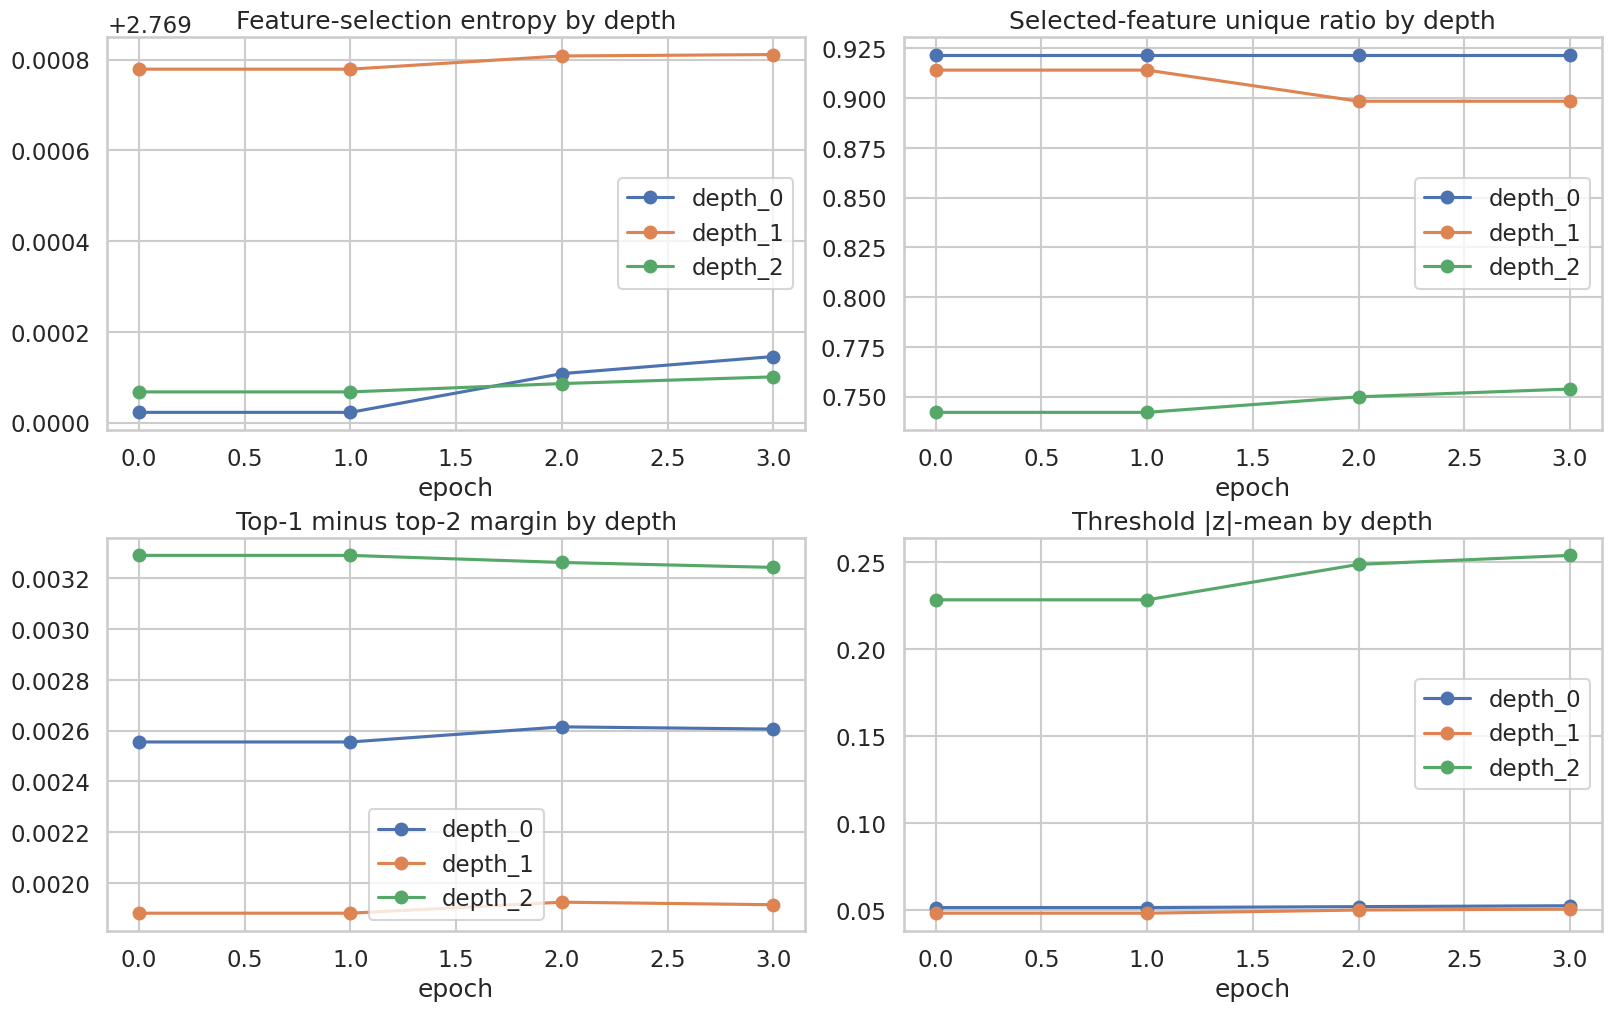

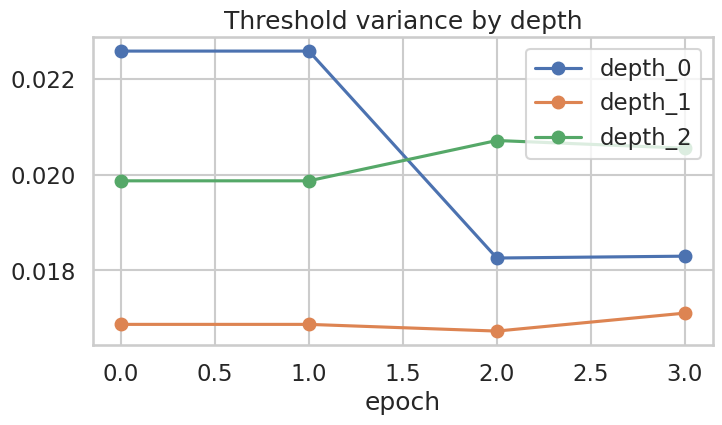

In [5]:
feature_entropy_keys = depth_sorted_keys(
    scalar_keys,
    prefix="grande_diagnostics/feature_selection/depth_",
    suffix="/entropy",
)
feature_unique_ratio_keys = depth_sorted_keys(
    scalar_keys,
    prefix="grande_diagnostics/feature_selection/depth_",
    suffix="/unique_ratio",
)
feature_margin_keys = depth_sorted_keys(
    scalar_keys,
    prefix="grande_diagnostics/feature_selection/depth_",
    suffix="/top1_top2_margin",
)
threshold_zscore_keys = depth_sorted_keys(
    scalar_keys,
    prefix="grande_diagnostics/thresholds/depth_",
    suffix="/zscore_abs_mean",
)
threshold_variance_keys = depth_sorted_keys(
    scalar_keys,
    prefix="grande_diagnostics/thresholds/depth_",
    suffix="/variance",
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
plot_depth_metric(scalar_df, feature_entropy_keys, "Feature-selection entropy by depth", ax=axes[0, 0])
plot_depth_metric(scalar_df, feature_unique_ratio_keys, "Selected-feature unique ratio by depth", ax=axes[0, 1])
plot_depth_metric(scalar_df, feature_margin_keys, "Top-1 minus top-2 margin by depth", ax=axes[1, 0])
plot_depth_metric(scalar_df, threshold_zscore_keys, "Threshold |z|-mean by depth", ax=axes[1, 1])
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
plot_depth_metric(scalar_df, threshold_variance_keys, "Threshold variance by depth", ax=ax)
plt.show()


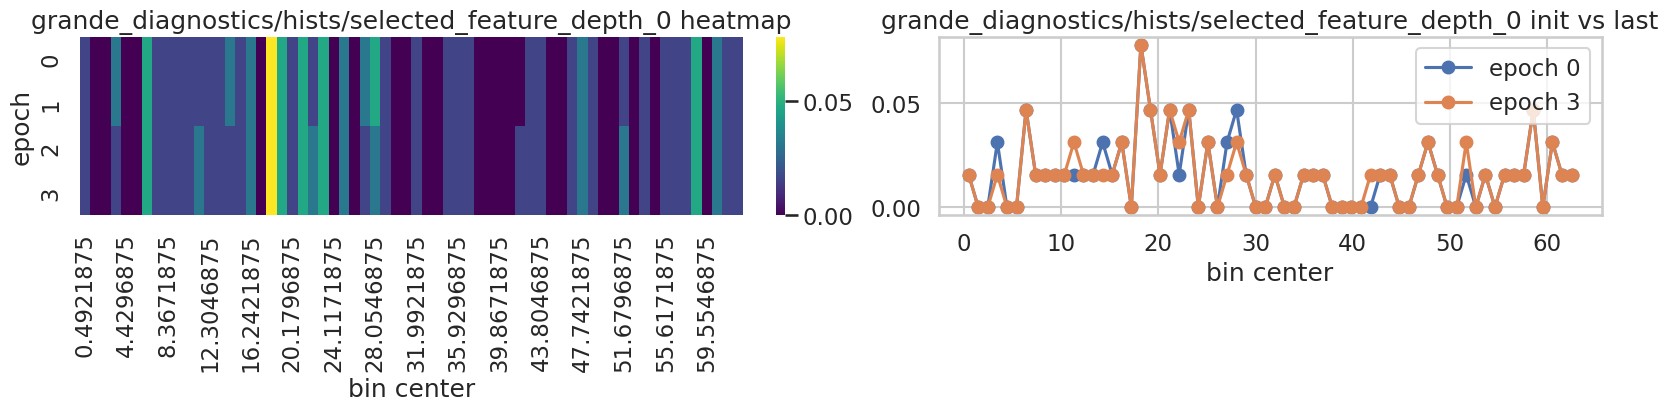

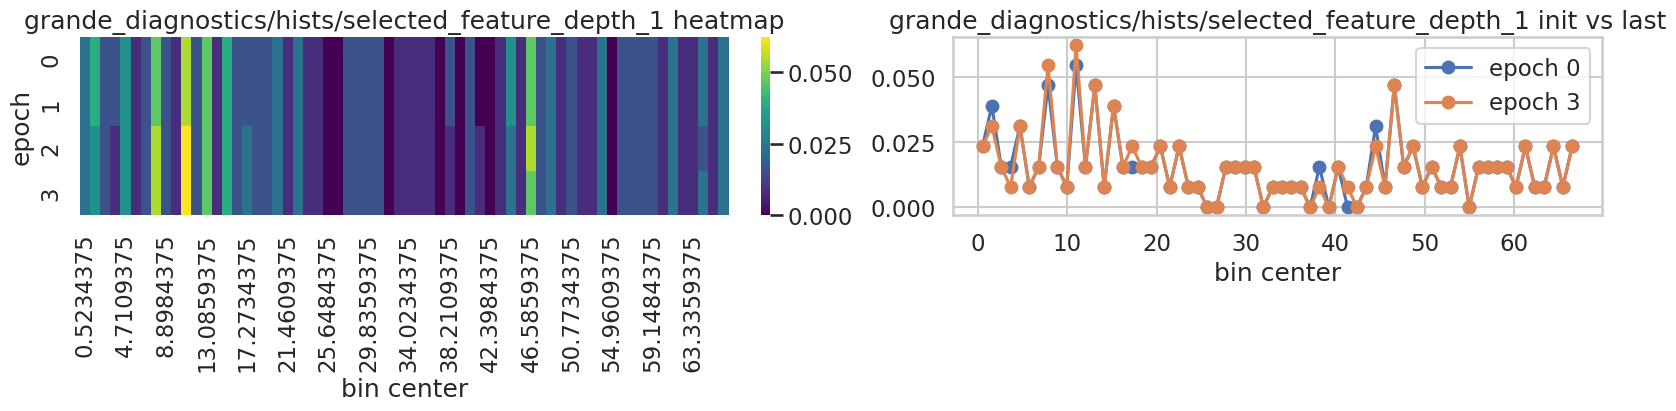

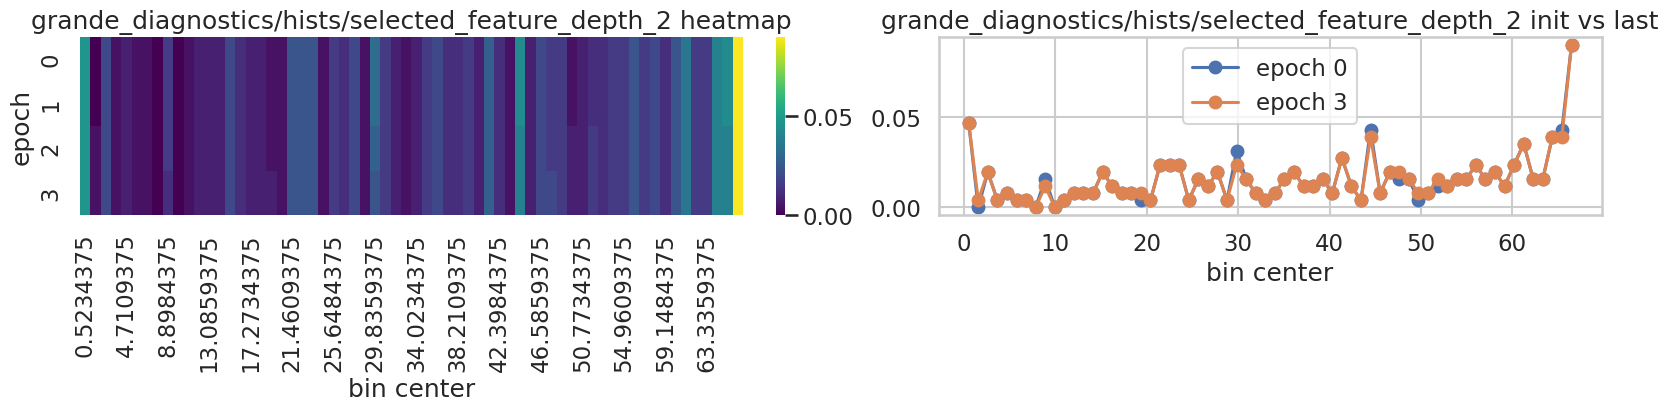

/home/mherre/miniconda3/envs/ticl/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


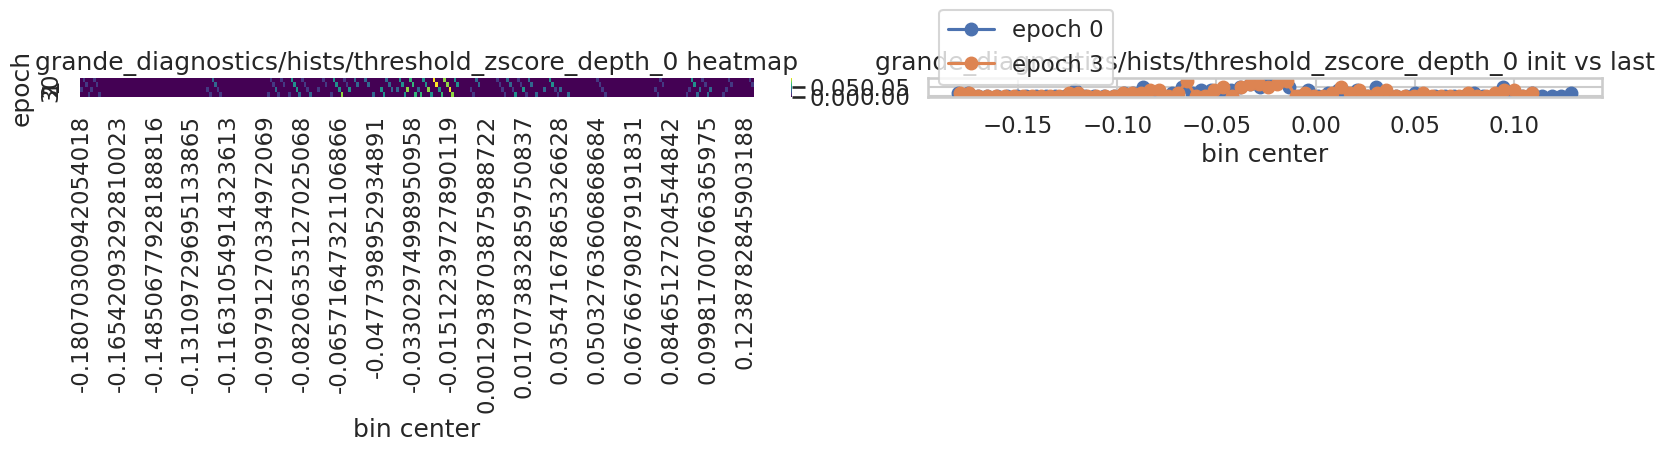

/home/mherre/miniconda3/envs/ticl/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


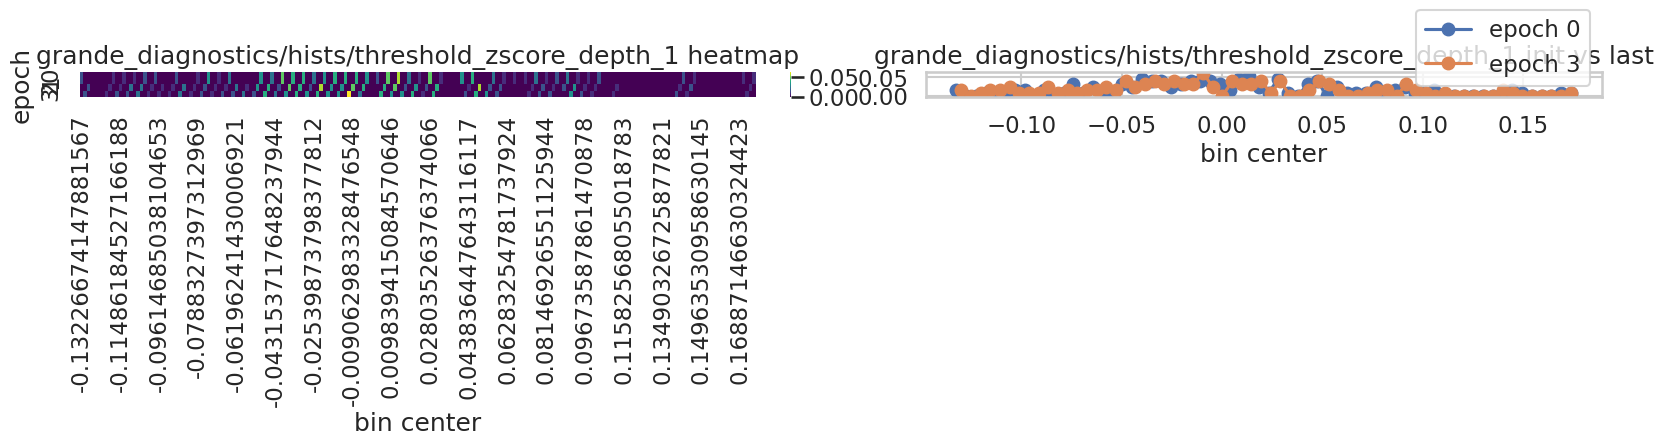

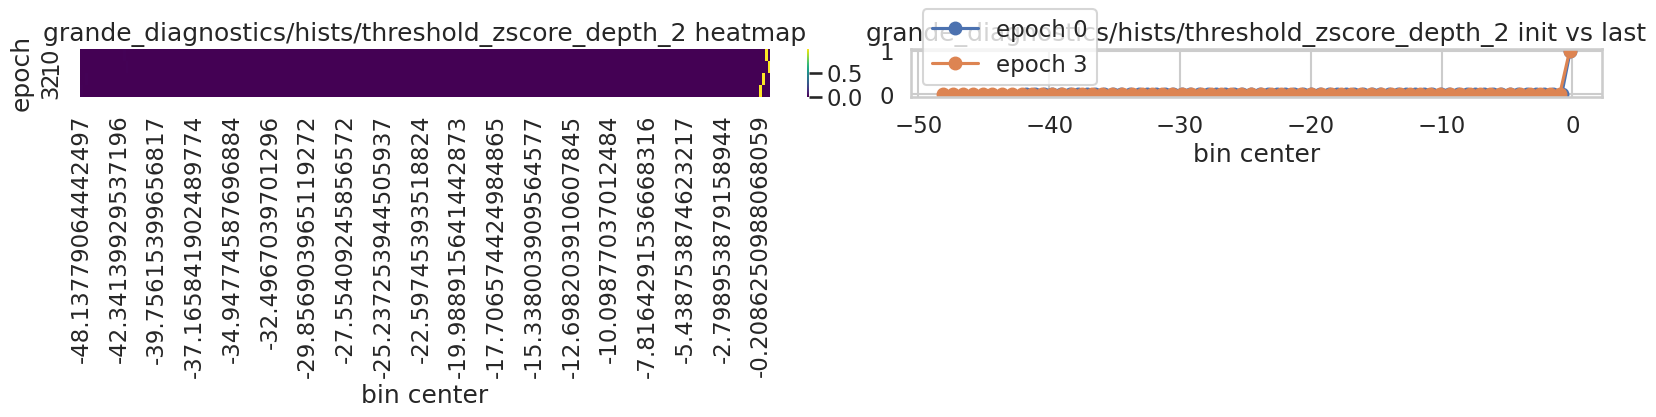

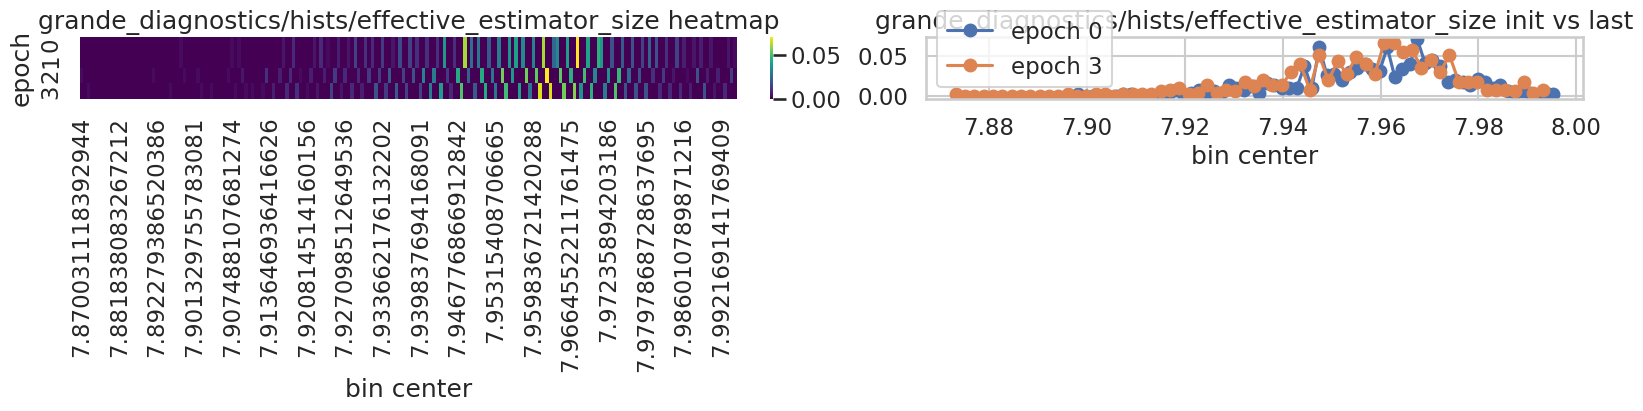

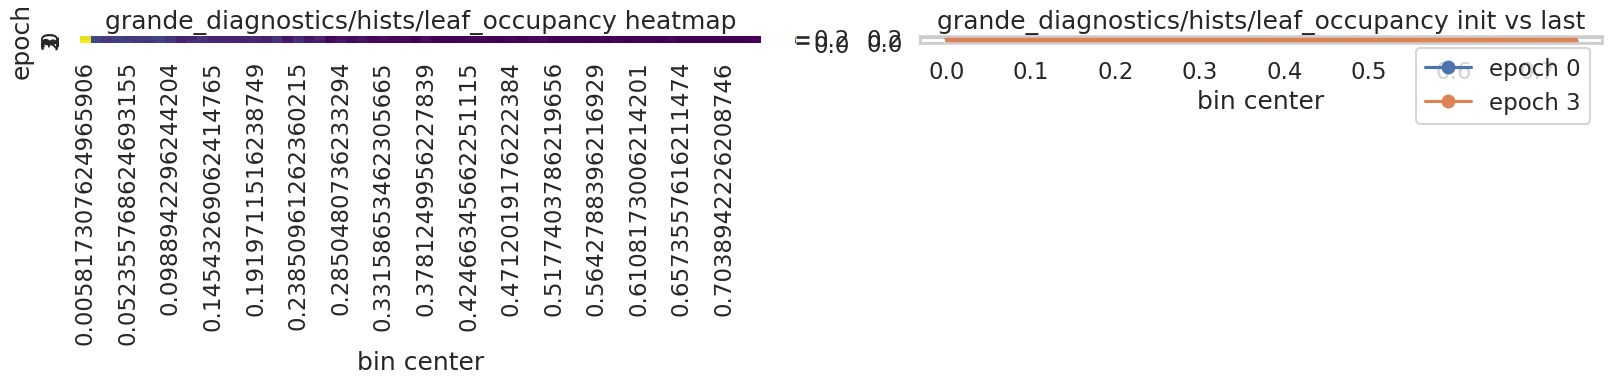

In [ ]:
selected_feature_hist_keys = sorted(
    key for key in grande_keys if key.startswith("grande_diagnostics/hists/selected_feature_depth_")
)
threshold_hist_keys = sorted(
    key for key in grande_keys if key.startswith("grande_diagnostics/hists/threshold_zscore_depth_")
)

for key in selected_feature_hist_keys:
    hist_df = histogram_to_frame(run, key)
    fig, axes = plt.subplots(1, 2, figsize=(16, 4), constrained_layout=True)
    plot_histogram_heatmap(hist_df, title=f"{key} heatmap", normalize=True, ax=axes[0])
    plot_histogram_overlay(hist_df, title=f"{key} init vs last", normalize=True, ax=axes[1])
    plt.show()

for key in threshold_hist_keys:
    hist_df = histogram_to_frame(run, key)
    fig, axes = plt.subplots(1, 2, figsize=(16, 4), constrained_layout=True)
    plot_histogram_heatmap(hist_df, title=f"{key} heatmap", normalize=True, ax=axes[0])
    plot_histogram_overlay(hist_df, title=f"{key} init vs last", normalize=True, ax=axes[1])
    plt.show()

for key in [
    "grande_diagnostics/hists/effective_estimator_size",
    "grande_diagnostics/hists/leaf_occupancy",
]:
    if key not in grande_keys:
        continue
    hist_df = histogram_to_frame(run, key)
    fig, axes = plt.subplots(1, 2, figsize=(16, 4), constrained_layout=True)
    plot_histogram_heatmap(hist_df, title=f"{key} heatmap", normalize=True, ax=axes[0])
    plot_histogram_overlay(hist_df, title=f"{key} init vs last", normalize=True, ax=axes[1])
    plt.show()


In [ ]:
gradient_keys = sorted(key for key in scalar_keys if "/gradients/" in key)
if not gradient_keys:
    print("No gradient diagnostics found for this run. Enable grande_diagnostics_gradients=True to populate them.")
else:
    param_grad_keys = [
        "grande_diagnostics/gradients/params/backbone/l2_norm",
        "grande_diagnostics/gradients/params/encoder/l2_norm",
        "grande_diagnostics/gradients/params/transformer_encoder/l2_norm",
        "grande_diagnostics/gradients/params/decoder/l2_norm",
    ]
    per_depth_split_keys = depth_sorted_keys(
        scalar_keys,
        prefix="grande_diagnostics/gradients/per_depth/split_values_depth_",
        suffix="_l2_norm",
    )
    per_depth_index_keys = depth_sorted_keys(
        scalar_keys,
        prefix="grande_diagnostics/gradients/per_depth/split_index_logits_depth_",
        suffix="_l2_norm",
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 4), constrained_layout=True)
    plot_scalar_panel(scalar_df, param_grad_keys, "Parameter gradient norms", ax=axes[0])
    plot_depth_metric(scalar_df, per_depth_split_keys, "Split-value gradient norms by depth", ax=axes[1])
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4))
    plot_depth_metric(scalar_df, per_depth_index_keys, "Split-index-logit gradient norms by depth", ax=ax)
    plt.show()


No gradient diagnostics found for this run. Enable grande_diagnostics_gradients=True to populate them.
